# 1. Restricting ligand–receptor methods with spatial proximity

Standard cell–cell communication methods — CellPhoneDB, NATMI, SingleCellSignalR, and
LIANA's consensus of them — take an expression matrix and a cell-type label, and ask:
*given that cell type A expresses the ligand and cell type B the receptor, how strong
and how specific is that interaction?* They were designed for dissociated scRNA-seq,
so they know nothing about geometry: two cell types at opposite ends of the tissue
score exactly like two cell types sitting on top of each other.

Restricting inference to cell types that are actually in spatial contact is therefore
not cosmetic — it removes predictions that cannot happen
([Dimitrov et al., 2022](https://doi.org/10.1038/s41467-022-30755-0);
[Dimitrov et al., 2024](https://doi.org/10.1038/s41556-024-01469-w)).

With single-cell resolution spatial data we can do exactly that. Here we:

1. measure how close each pair of cell types actually is, and
2. use that proximity to constrain a standard LR method — first as a **hard**
   restriction, then as a **soft** re-weighting.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

import liana as li

import warnings
warnings.filterwarnings("ignore")

adata = sc.read_h5ad("data/brain_section.h5ad")
adata

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'cell_type_colors', 'citation', 'log1p', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layer

## Cell type spatial proximity

This method finds pairwise proximity between cell types using minimum nearest-neighbor
distances in spatial coordinates (inspired by
[CellChatv2](https://www.nature.com/articles/s41596-024-01045-4)) and computes a
proximity score using a kernel function (e.g. Gaussian). <br>
Proximity scores are used for weighting ligand–receptor interactions by how strongly the
corresponding cell types co-localize across the whole slide.

Specifically, for each cell type pair $(A, B)$:

1. **Distance calculation**: Find nearest neighbor (euclidean) distances $d_i$ for each cell $i \in A$ to cells in $B$
   - For self-interactions $(A = A)$, exclude the cell itself (use 2nd nearest neighbor)

2. **Aggregation**: Compute trimmed mean distance
   $$\bar{d}_{A,B} = \text{trim\_mean}(\{d_i\}, \alpha)$$
   where $\alpha$ is the trim fraction (default: 0.1)

3. **Proximity score**: Apply kernel function (e.g. Gaussian $K(d, \sigma) = \exp\left(-\frac{d^2}{2\sigma^2}\right)$) to mean distance, where $\sigma$ is the bandwidth parameter controlling the spatial scale of proximity.
   $$p_{A,B} = K(\bar{d}_{A,B}, \sigma)$$

4. **Multiply** each ligand–receptor interaction score between cell types $A$ and $B$ by proximity score $p_{A,B}$ to get proximity-weighted interaction scores.

### Calculate cell pair proximity on its own

### What is the bandwidth?

`bandwidth` ($\sigma$) is a **distance, in the units of the spatial coordinates — microns
here**. It sets how fast proximity decays with spatial distance.

In [2]:
bandwidth = 30

In [3]:
pair_proximity = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian', bandwidth=bandwidth, spatial_key='X_spatial_coords', verbose=True)

Computing cell type proximities: 100%|██████████| 484/484 [00:06<00:00, 72.21it/s]


**interacting** is a binary flag: **0** if too few cells are co-localized across two cell
types for them to be considered as interacting, and 1 otherwise. <br>
**proximity** is a spatial co-localization weight between two cell types, bound between 0
and 1 (based on the `bandwidth`). Higher values mean closer proximity and stronger
interactions; lower values reflect weaker or no spatial co-localization.

In [4]:
pair_proximity.sort_values('proximity', ascending=True).head(3)

,source,target,mean_distance,interacting,proximity
234,histaminergic neuron,neuroblast (sensu Vertebrata),1506.719460,0,0.0
167,ependymal cell,monocyte,1402.563690,0,0.0
419,smooth muscle cell,cholinergic neuron,3877.382295,0,0.0


<Axes: xlabel='target', ylabel='source'>

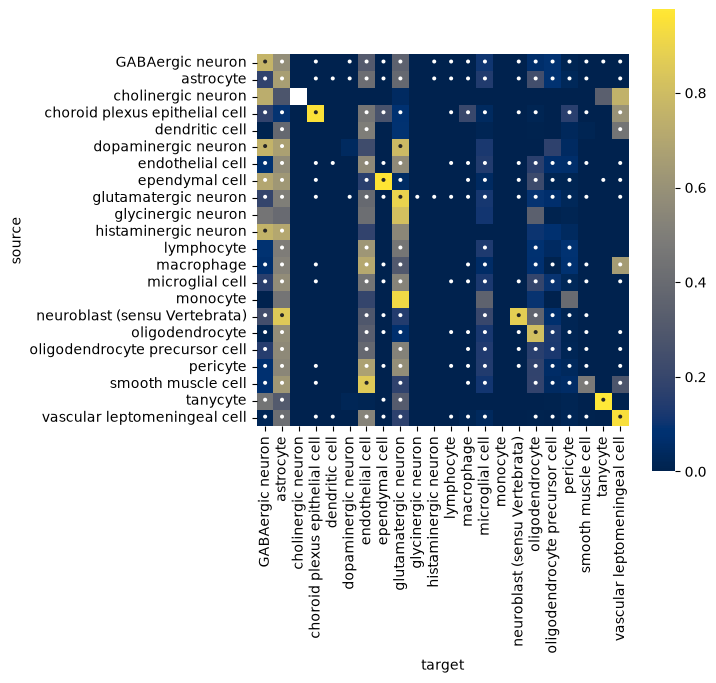

In [5]:
plt.figure(figsize=(6, 6))
proximity = 'proximity'
interacting = 'interacting'
sns.heatmap(
    data=pair_proximity.pivot(index='source', columns='target', values=proximity),
    annot=pair_proximity.pivot(index='source', columns='target', values=interacting).fillna(0).astype(int).replace({1: '•', 0: ''}),
    fmt='',
    annot_kws={'fontfamily': 'DejaVu Sans'},
    cmap='cividis',
    square=True
)

The heatmap indicates that e.g. the **smooth muscle cell** and **tanycyte** pair did not
meet the interaction criteria (`interacting == 0`). The spatial plot below shows why:
despite the abundance of smooth muscle cells (n = 4314), tanycytes are highly localized,
lacking sufficient proximity to smooth muscle cells to pass the filter.

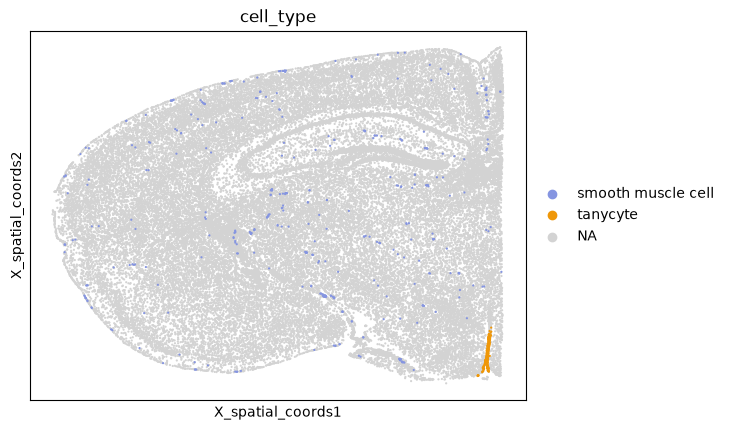

In [6]:
sc.pl.embedding(
    adata,
    basis="X_spatial_coords",
    color="cell_type",
    groups=["smooth muscle cell", "tanycyte"],
    s=10,
)

## Constrain LR inference by cell type pair proximity

`li.mt.rank_aggregate` runs several standard LR methods and aggregates their rankings.
The proximity table above can constrain it in two ways:

- **Hard** — pass only the co-localized cell type pairs via `groupby_pairs`, so distant
  pairs are never scored. This is the *microenvironment* idea of
  [CellPhoneDBv3](https://doi.org/10.1038/s41588-021-00972-2).
- **Soft** — pass `spatial_key` so every score is multiplied by the pair's proximity,
  as in [CellChatv2](https://doi.org/10.1038/s41596-024-01045-4).

We run all three variants — unconstrained, hard, soft — on the same data, and track the
same interactions across them.

In [7]:
# (a) the standard, non-spatial run -- what you would get from dissociated scRNA-seq
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     key_added='liana_res_plain',
                     )

Using resource `mouseconsensus`.
Using `.X`!
0.83 of entities in the resource are missing from the data.
100%|██████████| 1000/1000 [00:01<00:00, 651.95it/s]


Generating ligand-receptor stats for 51535 samples and 113 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### (i) Hard restriction — microenvironments

`interacting == 1` already defines which cell type pairs are close enough to signal.
Passing those pairs as `groupby_pairs` restricts inference to them.

`groupby_pairs` takes any list of source/target pairs, so the restriction does not have to
come from spatial data at all — prior knowledge of how a tissue is organised does the same
job. That is what a CellPhoneDBv3 *microenvironment* is. Either way it is a coarse
instrument: one decision per cell type pair for the whole section, which says nothing
about *where* or *at what distance* an interaction happens. Notebooks 02 and 03 take that up.

In [8]:
microenv = pair_proximity.query("interacting == 1")[["source", "target"]]
print(f"{len(microenv)}/{len(pair_proximity)} cell type pairs kept")

li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     groupby_pairs=microenv,
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     key_added='liana_res_micro',
                     )

Using resource `mouseconsensus`.
Using `.X`!
0.83 of entities in the resource are missing from the data.
100%|██████████| 1000/1000 [00:01<00:00, 660.28it/s]


224/483 cell type pairs kept
Generating ligand-receptor stats for 51535 samples and 113 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


### (ii) Soft weighting — proximity as a weight

Instead of removing distant pairs, multiply every interaction score by the proximity of
its cell type pair, so that pairs which do meet are additionally graded by how far apart
they are.

In [9]:
# (b) the same run, restricted by how close the cell types actually are
li.mt.rank_aggregate(adata,
                     groupby='cell_type',
                     spatial_key='X_spatial_coords',
                     resource_name='mouseconsensus',
                     expr_prop=0.01,
                     use_raw=False,
                     verbose=True,
                     spatial_kwargs={'kernel':'gaussian', 'bandwidth':bandwidth},
                     )

Using resource `mouseconsensus`.
Using `.X`!
0.83 of entities in the resource are missing from the data.
100%|██████████| 1000/1000 [00:01<00:00, 684.50it/s]


Generating ligand-receptor stats for 51535 samples and 113 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [10]:
adata.uns["liana_res"].sort_values(['magnitude_rank', 'lrscore'], ascending=(True, False)).head(3)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
3225,choroid plexus epithelial cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1,Gpc4,2.640270,2.298673,0.599462,0.534946,2.352476,0.0,5.781583,1.265780,2.080940,0.016574,0.800850,6.680704e-07,4.409998e-11
5640,dopaminergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,3.086861,3.484807,0.764706,0.766125,2.596726,0.0,8.501122,0.979155,1.587314,0.034875,0.691801,6.037472e-08,6.084748e-10
24038,tanycyte,tanycyte,Efna5,Ephb1,Efna5,Ephb1,2.253525,1.674578,0.543956,0.406593,1.917508,0.0,3.684274,0.725390,1.101634,0.022737,0.787126,6.680704e-07,1.729998e-09


### What did constraining change?

In [11]:
keys = ["source", "target", "ligand_complex", "receptor_complex"]

def positions(key, name):
    df = adata.uns[key][keys + ["magnitude_rank"]].copy()
    df[name] = df["magnitude_rank"].rank(method="first").astype(int)
    return df.drop(columns="magnitude_rank")

cmp = (positions("liana_res_plain", "pos_plain")
       .merge(positions("liana_res_micro", "pos_micro"), on=keys, how="left")
       .merge(adata.uns["liana_res"][keys + ["magnitude_rank"]], on=keys, how="left")
       .rename(columns={"magnitude_rank": "mrank_soft"}))

print(f"{len(cmp)} interactions unconstrained; "
      f"{int(cmp['pos_micro'].notna().sum())} survive the microenvironment filter\n")

removed = cmp[cmp["pos_micro"].isna()]
print("Best-ranked interactions that proximity removes:")
print(removed.nsmallest(5, "pos_plain")[keys + ["pos_plain", "mrank_soft"]].to_string(index=False))


25683 interactions unconstrained; 16385 survive the microenvironment filter

Best-ranked interactions that proximity removes:
              source               target ligand_complex receptor_complex  pos_plain  mrank_soft
histaminergic neuron histaminergic neuron            Hdc             Hrh3          1         1.0
    endothelial cell             tanycyte            Fn1             Tshr          5         1.0
histaminergic neuron   glycinergic neuron            Hdc             Hrh3          7         1.0
 dopaminergic neuron histaminergic neuron        Col18a1             Gpc4         10         1.0
 dopaminergic neuron   glycinergic neuron          Efna5            Epha7         11         1.0


Interactions that the unconstrained run puts at the very top — including rank 1 — involve
cell types that never meet on this section. The hard filter removes them; the soft run
keeps them but assigns the worst possible aggregate rank (`mrank_soft == 1`). Their
expression evidence is identical in both cases, which is exactly the failure mode a
non-spatial method cannot see.

Two caveats worth stating: `groupby_pairs` also shrinks the set over which permutation
p-values are computed, so ranks in the hard run shift for reasons beyond the filter; and
in the soft run a large fraction of interactions saturate at the worst rank, so
*positions* within that block are ties and not interpretable.

### Visualise the proximity-weighted result

Interactions from **glutamatergic neurons** to various target cell types, ranked by
**specificity** — how much a cell type pair stands out against the rest — with colour
showing magnitude (`lr_means`). Both are proximity-weighted here.

`inverse_size=True` plots $-\log_{10}$ of the rank, so **bigger dots are more specific**
even though the legend keeps the `specificity_rank` name: 6 on that scale means $p \approx
10^{-6}$, and 0 means $p \approx 1$.


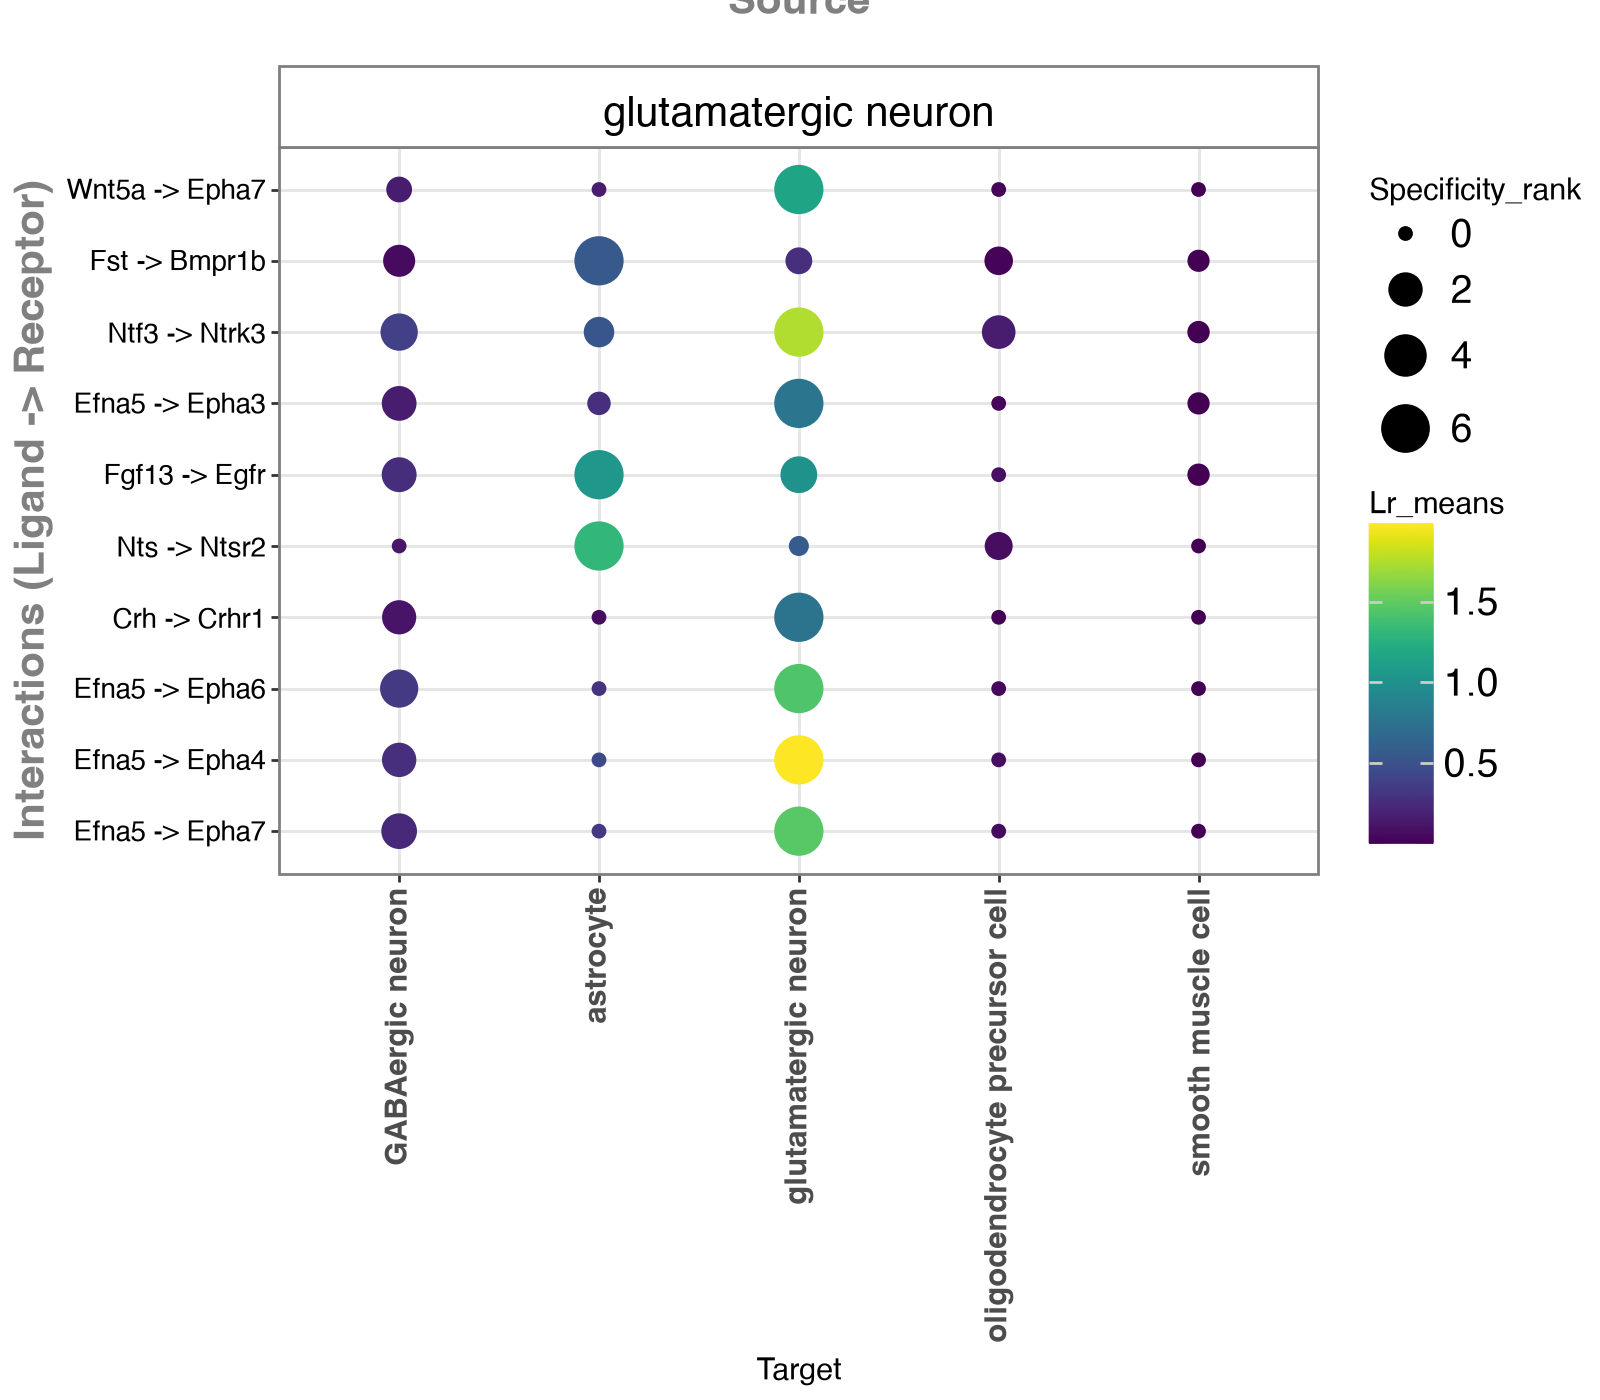

In [12]:
li.pl.dotplot(adata = adata,
              colour='lr_means',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=False,
              source_labels=["glutamatergic neuron"],
              target_labels=["glutamatergic neuron", "GABAergic neuron", "astrocyte", "oligodendrocyte precursor cell", "smooth muscle cell"],
              top_n=10,
              orderby='specificity_rank',
              orderby_ascending=True,
              figure_size=(8, 7)
             )


The same interaction (`Ntf3 → Ntrk3`) under all three runs, on a shared colour scale.

**Grey** cells were removed by the hard filter. **Dark** cells in the soft panel are a
different thing — still scored, but multiplied by a small proximity; 102 of the 172
survivors are merely graded down, which is what the soft variant adds over the hard one.
At $\sigma = 30$ µm that panel is nearly black: the median cell type pair on this section
sits ~250 µm apart, more than eight bandwidths.

The two runs do not agree exactly: 92 cells are grey, but 108 are zero in the soft panel.
The 17 cell type pairs responsible pass `interacting` — a **local** test, at least
`min_cells_in_proximity` cells within one bandwidth — yet their **trimmed mean** distance
is over a millimetre, so the Gaussian returns zero. At $\sigma = 100$ the two criteria
agreed; at $\sigma = 30$ they come apart.


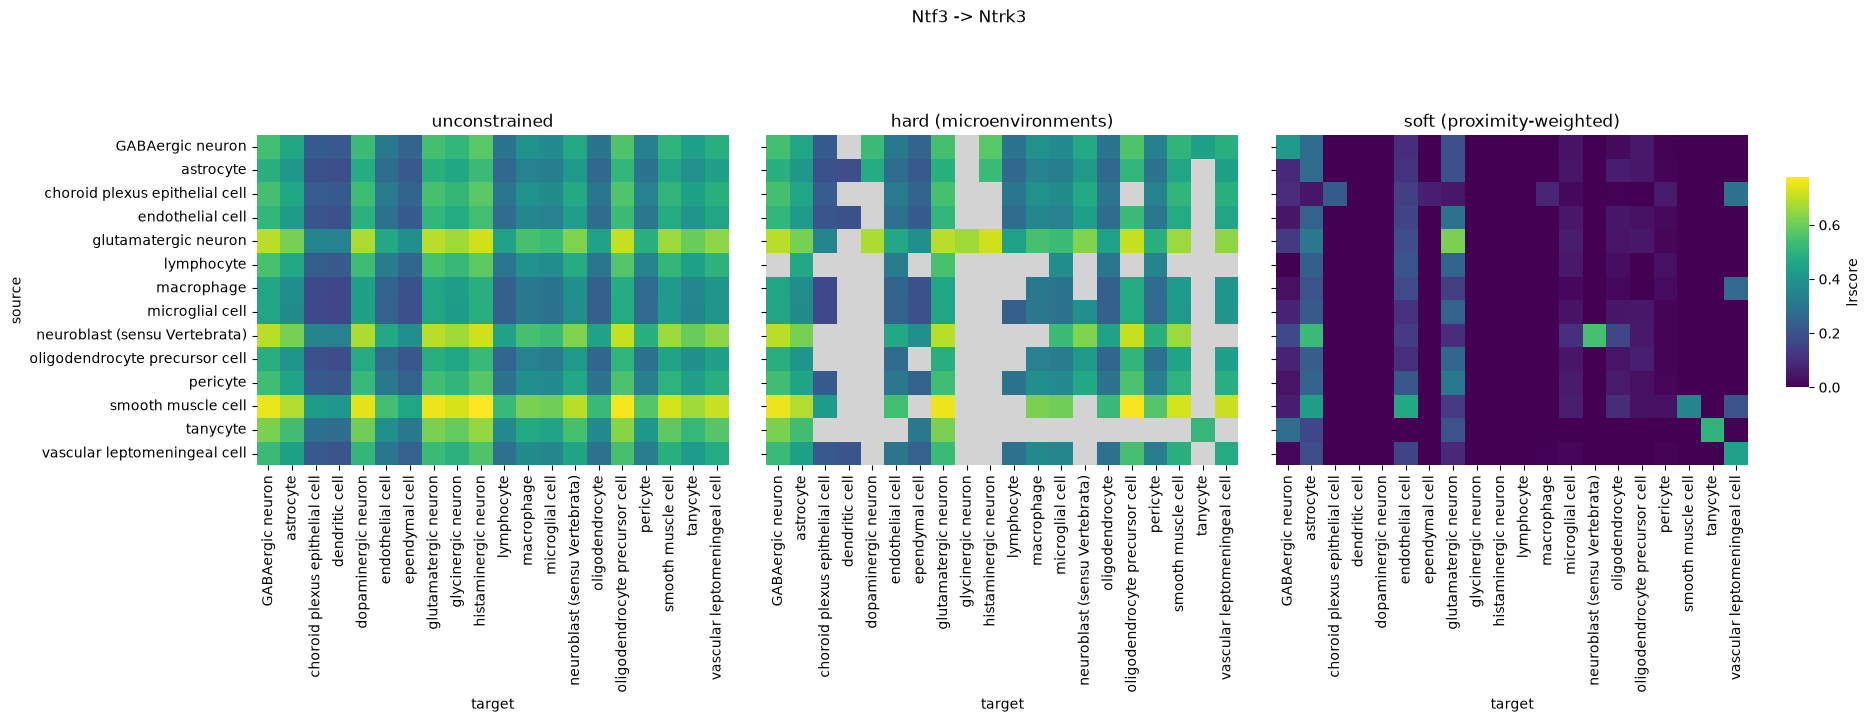

In [13]:
runs = [("liana_res_plain", "unconstrained"),
        ("liana_res_micro", "hard (microenvironments)"),
        ("liana_res", "soft (proximity-weighted)")]

mats = {}
for key, _ in runs:
    d = adata.uns[key]
    d = d[(d['ligand_complex'] == 'Ntf3') & (d['receptor_complex'] == 'Ntrk3')]
    mats[key] = d.pivot_table(index='source', columns='target', values='lrscore')

sources = sorted(set().union(*[m.index for m in mats.values()]))
targets = sorted(set().union(*[m.columns for m in mats.values()]))
vmax = max(m.max().max() for m in mats.values())

fig, axes = plt.subplots(1, 3, figsize=(19, 6), sharey=True)
fig.subplots_adjust(right=0.91, wspace=0.08)
cbar_ax = fig.add_axes((0.93, 0.35, 0.012, 0.35))

for ax, (key, title) in zip(axes, runs):
    sns.heatmap(mats[key].reindex(index=sources, columns=targets),
                ax=ax, cmap='viridis', vmin=0, vmax=vmax, square=True,
                cbar=(key == runs[-1][0]), cbar_ax=cbar_ax,
                cbar_kws={'label': 'lrscore'})
    ax.set_facecolor('lightgrey')   # grey = cell type pair not scored at all
    ax.set_title(title)
    ax.set_ylabel('source' if ax is axes[0] else '')

fig.suptitle('Ntf3 -> Ntrk3')
plt.show()


---

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 1 — How much does the bandwidth matter?**

`bandwidth=30` (µm) decides how quickly proximity decays with distance — and therefore
which cell type pairs count as interacting at all.

Re-run `li.pp.spatial_pair_proximity` with `bandwidth=100` and `bandwidth=300`, and count
how many cell type pairs are flagged `interacting == 1` in each case.

Which bandwidth would you defend for a MERFISH brain section, and on what grounds?
</div>

In [14]:
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    # ... how many pairs are interacting? what is the median proximity?
    print(bw)

30
100
300


<details>
<summary><b>▶ Solution</b></summary>

```python
for bw in [30, 100, 300]:
    pp = li.pp.spatial_pair_proximity(adata, groupby='cell_type', kernel='gaussian',
                                      bandwidth=bw, spatial_key='X_spatial_coords')
    print(f"bandwidth={bw:>4} µm | interacting pairs: {int(pp['interacting'].sum()):>3}/{len(pp)}"
          f" | median proximity: {pp['proximity'].median():.3f}")
```

A small bandwidth admits only cell types that are essentially touching; a large one lets
almost every pair through and the weighting stops discriminating.

There is no single correct answer, but there is a defensible one: the bandwidth should
reflect the **signalling range you care about**, not the size of the tissue. Juxtacrine
and short-range paracrine signalling operates over roughly one to a few cell diameters
(~10–50 µm here), which is why `30` µm is used above. `100` µm and beyond is permissive —
it keeps genuinely neighbouring populations but also lets in cell types sitting in
different anatomical compartments.

</details>

<div style="border-left:5px solid #2e7d32; background:#f1f8e9; padding:10px 14px; border-radius:4px; margin:12px 0;">

**🧪 Exercise 2 — Follow your own interaction**

Pick a different ligand–receptor pair, or a different sender cell type, from the ranked
table and remake the heatmap above.

```python
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)
```

Does your interaction look plausible given the proximity heatmap from earlier — i.e. are
its top cell type pairs ones that actually co-localize?
</div>

In [15]:
# your turn
adata.uns["liana_res"].sort_values("magnitude_rank").head(20)

,source,target,ligand_complex,receptor_complex,ligand,receptor,ligand_means,receptor_means,ligand_props,receptor_props,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
3225,choroid plexus epithelial cell,choroid plexus epithelial cell,Col18a1,Gpc4,Col18a1,Gpc4,2.640270,2.298673,0.599462,0.534946,2.352476,0.000,5.781583,1.265780,2.080940,0.016574,0.800850,6.680704e-07,4.409998e-11
5640,dopaminergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,3.086861,3.484807,0.764706,0.766125,2.596726,0.000,8.501122,0.979155,1.587314,0.034875,0.691801,6.037472e-08,6.084748e-10
24038,tanycyte,tanycyte,Efna5,Ephb1,Efna5,Ephb1,2.253525,1.674578,0.543956,0.406593,1.917508,0.000,3.684274,0.725390,1.101634,0.022737,0.787126,6.680704e-07,1.729998e-09
24085,tanycyte,tanycyte,Rspo3,Lgr6,Rspo3,Lgr6,1.429885,2.507174,0.346154,0.582418,1.921879,0.000,3.500014,1.776939,2.798013,0.139527,0.783182,1.256670e-09,1.733306e-09
5638,dopaminergic neuron,glutamatergic neuron,Efna5,Epha10,Efna5,Epha10,3.086861,2.393576,0.764706,0.568773,2.165537,0.000,5.839084,0.955379,1.707613,0.050897,0.674437,2.547803e-08,4.284324e-09
21763,smooth muscle cell,endothelial cell,Spp1,S1pr1,Spp1,S1pr1,0.908050,4.076341,0.206549,0.826147,2.138378,0.000,3.176016,0.742262,1.495940,0.007794,0.690473,6.680704e-07,4.292516e-09
5642,dopaminergic neuron,glutamatergic neuron,Efna5,Epha7,Efna5,Epha7,3.086861,2.341524,0.764706,0.552636,2.144969,0.000,5.712105,0.953288,1.737103,0.037140,0.673346,2.811088e-08,4.867798e-09
5641,dopaminergic neuron,glutamatergic neuron,Efna5,Epha6,Efna5,Epha6,3.086861,2.269548,0.764706,0.536847,2.116529,0.000,5.536521,0.941365,1.666084,0.041697,0.671782,3.708413e-08,6.188977e-09
25667,vascular leptomeningeal cell,vascular leptomeningeal cell,Spp1,S1pr1,Spp1,S1pr1,2.513404,1.386788,0.526579,0.317699,1.839464,0.000,3.287817,0.999771,1.619229,0.008069,0.754570,6.680704e-07,6.930908e-09
9530,glutamatergic neuron,glutamatergic neuron,Efna5,Epha4,Efna5,Epha4,0.939284,3.484807,0.241719,0.766125,1.982086,0.000,2.932947,0.408830,1.333576,0.012032,0.712242,6.680704e-07,6.944160e-09


<details>
<summary><b>▶ Solution</b></summary>

Any well-ranked pair works. The check that matters is consistency: because every score
was multiplied by `proximity`, a highly ranked interaction *cannot* involve a cell type
pair with proximity near zero. So the top of this table should only ever contain pairs
that look bright in the proximity heatmap.

If you pick an interaction and find its best cell type pair is one you know to be
anatomically separated, that is a sign the proximity bandwidth is too permissive — which
is exactly what Exercise 1 was probing.

</details>

---

## References

- Dimitrov et al. (2022) Comparison of methods and resources for cell-cell communication
  inference from single-cell RNA-Seq data. *Nature Communications* 13:3224.
  [doi:10.1038/s41467-022-30755-0](https://doi.org/10.1038/s41467-022-30755-0)
- Dimitrov et al. (2024) LIANA+ provides an all-in-one framework for cell–cell
  communication inference. *Nature Cell Biology* 26:1613–1622.
  [doi:10.1038/s41556-024-01469-w](https://doi.org/10.1038/s41556-024-01469-w)
- Garcia-Alonso et al. (2021) Mapping the temporal and spatial dynamics of the human
  endometrium in vivo and in vitro. *Nature Genetics* 53:1698–1711 — CellPhoneDBv3
  microenvironments. [doi:10.1038/s41588-021-00972-2](https://doi.org/10.1038/s41588-021-00972-2)
- Jin et al. (2024) CellChat for systematic analysis of cell–cell communication from
  single-cell transcriptomics. *Nature Protocols* — CellChatv2, spatially informed
  inference. [doi:10.1038/s41596-024-01045-4](https://doi.org/10.1038/s41596-024-01045-4)

---

**Next:** notebook 02 asks a sharper question — not *are these cell types near each other
on average*, but *at what distance* is a given interaction enriched.